In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle

In [12]:
dim_set = [2, 5, 10]
mb_set = [16, 32, 64, 128, 256, 512, 1024]
seed_set = [0,1,2]

In [4]:
results = dict()

score_set = np.empty((4, len(dim_set), len(mb_set), len(seed_set)))
score_kmeans_set = np.empty((4, len(dim_set), len(mb_set), len(seed_set)))
score_gmm_set = np.empty((4, len(dim_set), len(mb_set), len(seed_set)))

In [14]:
for k, seed in enumerate(seed_set):
    for i, dim in enumerate(dim_set):
        foldername = f'W_D{dim}K4_mb16_ds42_debias_pifixed_kmeansinit_lr0.01_T50000_S{seed}'
        filename = './results/'+foldername+'/results.pickle'
        # load from pickle file
        with open(filename, "rb") as f:
            results[foldername] = pickle.load(f)

In [5]:
for k, seed in enumerate(seed_set):
    for j, mb in enumerate(mb_set):
        for i, dim in enumerate(dim_set):
            foldername = f'W_D{dim}K4_mb{mb}_ds42_pifixed_kmeansinit_lr0.01_T20000_S{seed}'
            filename = './results/'+foldername+'/results.pickle'
            # load from pickle file
            with open(filename, "rb") as f:
                results[foldername] = pickle.load(f)
            l = 0
            score_set[l,i,j,k] = results[foldername]['score'][-1]
            score_kmeans_set[l,i,j,k] = results[foldername]['score_kmeans']
            score_gmm_set[l,i,j,k] = results[foldername]['score_GMM']
                
            foldername = f'W_D{dim}K4_mb{mb}_ds42_debias_pifixed_kmeansinit_lr0.01_T20000_S{seed}'
            filename = './results/'+foldername+'/results.pickle'
            # load from pickle file
            with open(filename, "rb") as f:
                results[foldername] = pickle.load(f)
            l = 1
            score_set[l,i,j,k] = results[foldername]['score'][-1]
            score_kmeans_set[l,i,j,k] = results[foldername]['score_kmeans']
            score_gmm_set[l,i,j,k] = results[foldername]['score_GMM']

            foldername = f'W_D{dim}K4_mb{mb}_ds42_pifixed_fixdata_kmeansinit_lr0.01_T20000_S{seed}'
            filename = './results/'+foldername+'/results.pickle'
            # load from pickle file
            with open(filename, "rb") as f:
                results[foldername] = pickle.load(f)
            l = 2
            score_set[l,i,j,k] = results[foldername]['score'][-1]
            score_kmeans_set[l,i,j,k] = results[foldername]['score_kmeans']
            score_gmm_set[l,i,j,k] = results[foldername]['score_GMM']

            foldername = f'W_D{dim}K4_mb{mb}_ds42_debias_pifixed_fixdata_kmeansinit_lr0.01_T20000_S{seed}'
            filename = './results/'+foldername+'/results.pickle'
            # load from pickle file
            with open(filename, "rb") as f:
                results[foldername] = pickle.load(f)
            l = 3
            score_set[l,i,j,k] = results[foldername]['score'][-1]
            score_kmeans_set[l,i,j,k] = results[foldername]['score_kmeans']
            score_gmm_set[l,i,j,k] = results[foldername]['score_GMM']

In [6]:
score_set_mean = np.mean(score_set, axis=-1)
score_set_std = np.std(score_set, axis=-1, ddof=0)

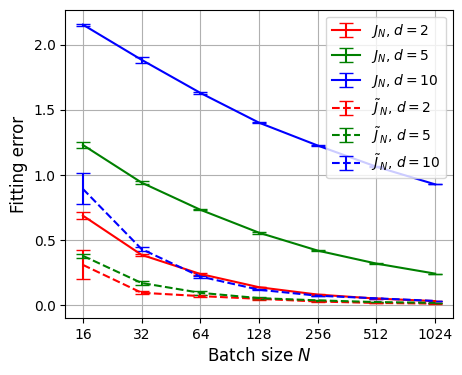

In [50]:
cur_dim_set = [2,5,10]
cur_dimidx_set = [0,1,2]
colors = ['r', 'g', 'b']
l_set = [0,1]
ls_set = ['solid', '--', '-.', ':']

plt.figure(figsize=(5,4))
for j, dim in enumerate(cur_dim_set):
    i = cur_dimidx_set[j]
    l=0
    plt.errorbar(np.arange(len(mb_set)), score_set_mean[l,i], 
                     yerr=score_set_std[l,i], color=colors[j], ls=ls_set[l], label=rf"$J_N$, $d={dim}$", capsize=5)
for j, dim in enumerate(cur_dim_set):
    i = cur_dimidx_set[j]
    l=1
    plt.errorbar(np.arange(len(mb_set)), score_set_mean[l,i], 
                     yerr=score_set_std[l,i], color=colors[j], ls=ls_set[l], label=rf"$\tilde J_N$, $d={dim}$", capsize=5)
# for j, dim in enumerate(cur_dim_set):
#     i = cur_dimidx_set[j]
#     plt.plot(np.arange(len(mb_set)),score_kmeans_set[0,i,:,0], label=r'$d$'+f'={dim} (init)')

# for j, dim in enumerate(cur_dim_set):
#     i = cur_dimidx_set[j]
#     plt.plot(np.arange(len(mb_set)),score_gmm_set[0,i,:,0], label=r'$d$'+f'={dim} (gmm)')
    
# plt.legend()
plt.grid()
plt.legend()
plt.xlabel(r'Batch size $N$', fontsize=12)
plt.ylabel('Fitting error', fontsize=12)
plt.xticks([0,1,2,3,4,5,6], labels=["16", "32", "64", "128", "256", "512", "1024"])
# plt.xlim([-10,10])
# plt.ylim([-0.5, 16])
# plt.savefig(f'./fig_GMM_fitting_error.pdf', format='pdf', bbox_inches="tight", dpi=300)